# Investigating the generated spectrum and detector response

In [4]:
import spekpy as sp
import matplotlib
import matplotlib.pyplot as plt

font = {'family' : 'serif',
            'size'   :  15
        }
matplotlib.rc('font', **font)

from gvxrPython3 import gvxr 
from gvxrPython3.utils import loadSpekpySpectrum
import ipynbname
import numpy as np

path = ipynbname.path()
BASE = path.parents[2] 


Parameters defining the polychromatic spectrum: 

In [8]:
mAs = 0.11            #  tube current-timeproduct 
z = 49                #  source-detector distance
keV = 60              #  tube voltage
th_in_deg = 12        #  anode angle
nbr_energy_bins = 50  
pixel_size = 0.1

filter = [ ["Al", 0.5, "mm"]]

How to generate spektrum with Spekpy directly: 

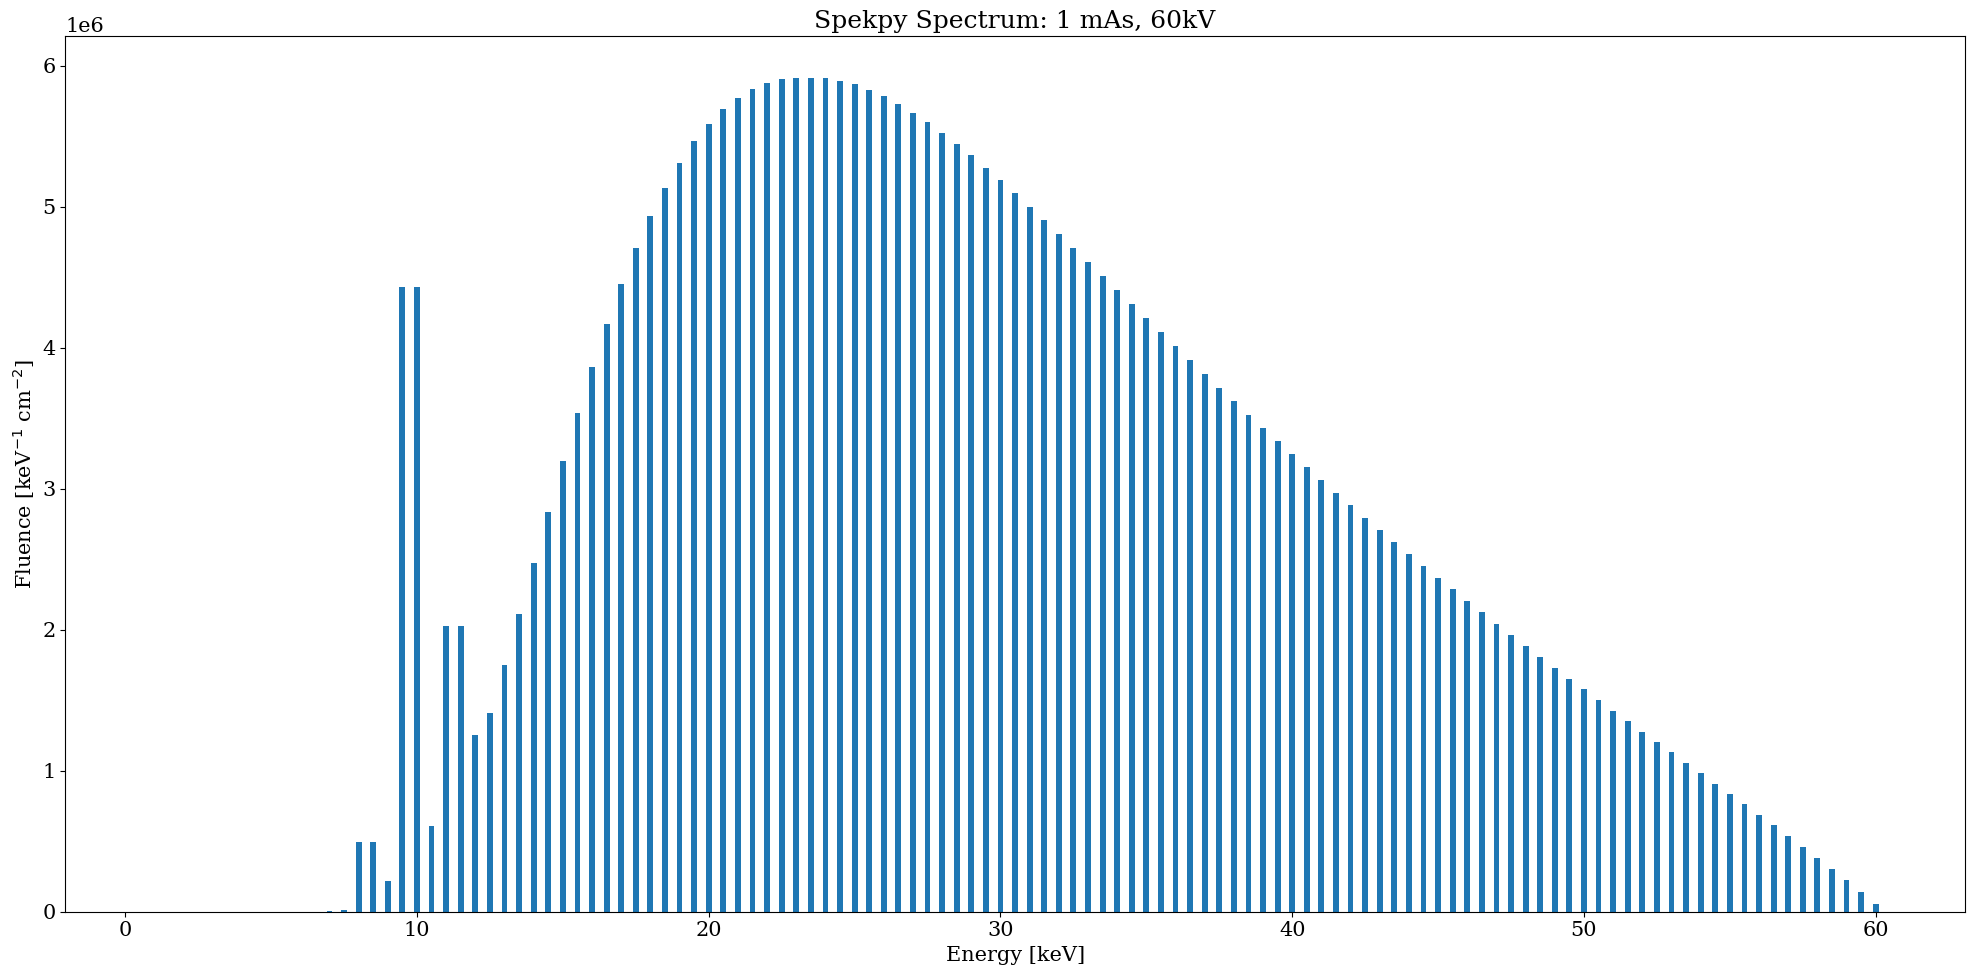

In [9]:
unit = "keV"
energy_bins = []
photon_counts = []

mAs = 1         # Tube-current time product 
z = 100         # Source-detector distance 
keV = 60        # Tube
th_in_deg = 12   

s = sp.Spek(kvp=keV, th=th_in_deg, mas=mAs, z=z)
s.filter("Al", 0.5)

# Get the spectrum. The photon counts is given in cm^2 at a distance of z from the source
energy_bins, photon_counts = s.get_spectrum(edges=True)


plt.figure(figsize= (20,10))
plt.bar(energy_bins, photon_counts, width=0.2)
plt.title(f"Spekpy Spectrum: {mAs} mAs, {keV}kV")
plt.xlabel('Energy [keV]')
plt.ylabel('Fluence [keV$^{-1}$ cm$^{-2}$]')
plt.tight_layout()
plt.show()


Integrated function in gVXR (converts fluence to photons per pixel):

s = sp.Spek(kvp= 60 , th= 12 , mas= 1 , z= 100
651887635.0032188  photons / cm^2
65188.763500321875  photons / pixel


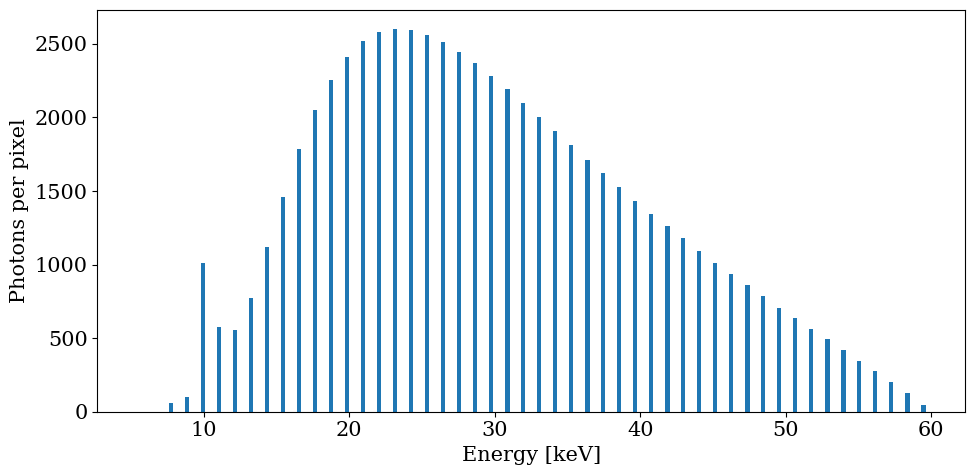

In [10]:
gvxr.createOpenGLContext()
gvxr.usePointSource() 
gvxr.setDetectorUpVector(0,0,-1)
gvxr.setDetectorNumberOfPixels(50,50)

gvxr.setDetectorPixelSize(pixel_size,pixel_size, "mm") 

loadSpekpySpectrum(keV, th_in_deg=12, max_number_of_energy_bins=nbr_energy_bins,
                                     mAs=mAs, z=z, filters=filter)  

energy_bins = gvxr.getEnergyBins("keV")
photon_count = np.array(gvxr.getPhotonCountEnergyBins(), dtype=float)

plt.figure(figsize= (10,5))
plt.bar(energy_bins, photon_count, width=0.3)
plt.xlabel('Energy [keV]')
plt.ylabel('Photons per pixel')
plt.tight_layout()
plt.show()

Energy dependant detector response: 

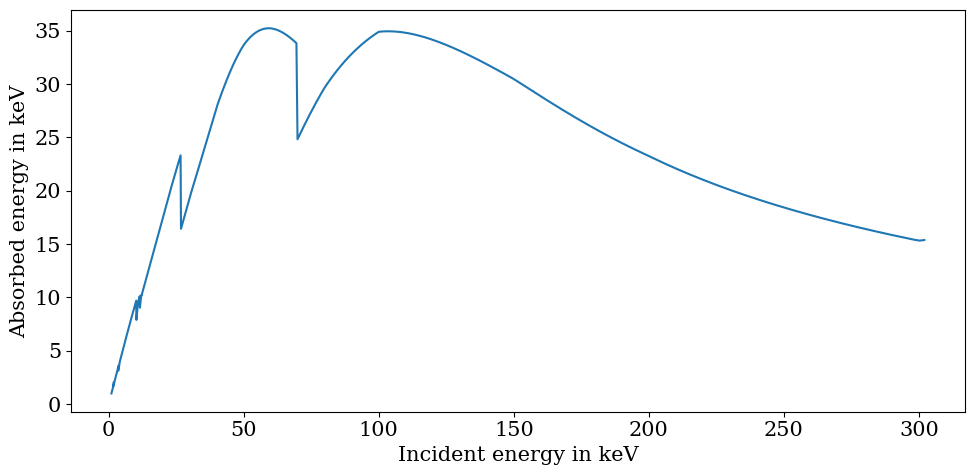

In [11]:
scintillator = "CdWO4"
thickness = 525

gvxr.setScintillator(scintillator, thickness, "um")

energy_response = np.array(gvxr.getEnergyResponse("keV"))

plt.figure(figsize= (10,5))
plt.plot(energy_response[:,0], energy_response[:,1])
plt.xlabel('Incident energy in keV')
plt.ylabel('Absorbed energy in keV')
plt.tight_layout()
plt.show()